
# 📘 GNN Midterm — WiFi Packet Attack Prediction (Edge Classification with GNN)
**Goal**: Train a GNN to predict the **`Attack_label`** on each directed edge (src → dst) using `packets.csv`, then predict the labels for `test2.csv` (where `Attack_label` is `?`).  
We treat `src`/`dst` as **nodes** and the remaining fields as **edge features**.

**Outputs**
1. Test **accuracy** (`TEST_SIZE=0.2`)
2. **Loss curve**
3. `test2.csv` → `Attack_label_pred` 출력 & `test2_pred.csv` 저장
4. **전체 소스코드**


In [1]:

import sys, torch, os
TORCH_VER = torch.__version__.split('+')[0]
CUDA_STR = f"+cu{torch.version.cuda.replace('.','')}" if torch.cuda.is_available() and torch.version.cuda else "+cpu"
pyg_index = f"https://data.pyg.org/whl/torch-{TORCH_VER}{CUDA_STR}.html"
print(f"Torch: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
print("Installing torch_geometric from:", pyg_index)
!pip -q install torch_geometric -f {pyg_index}


Torch: 2.8.0+cu126, CUDA available: False
Installing torch_geometric from: https://data.pyg.org/whl/torch-2.8.0+cpu.html


,src,dst,Packet_Size,Protocol,Encryption_Type,Packet_Delay(ms),Attack_label
0,Node_4,Node_1,627,TCP,AES-128,12.48,Replay_Attack
1,Node_18,Node_3,1273,UDP,AES-128,9.31,Replay_Attack
2,Node_20,Node_1,1213,TCP,AES-256,13.24,Normal
3,Node_18,Node_14,515,UDP,AES-256,17.62,Normal
4,Node_1,Node_7,1493,UDP,AES-192,8.83,Normal


,src,dst,Packet_Size,Protocol,Encryption_Type,Packet_Delay(ms),Attack_label
0,Node_7,Node_2,273,TCP,AES-192,8.83,?
1,Node_3,Node_4,845,UDP,AES-256,5.46,?
2,Node_1,Node_5,807,UDP,AES-128,7.28,?
3,Node_8,Node_7,1425,TCP,AES-128,7.51,?
4,Node_5,Node_2,883,TCP,AES-128,7.44,?


[   1] train_loss=1.3686 val_loss=0.7966 | train_acc=0.853 val_acc=0.853 (best=0.853)
[  10] train_loss=0.5858 val_loss=0.5847 | train_acc=0.853 val_acc=0.853 (best=0.853)
[  20] train_loss=0.5871 val_loss=0.5807 | train_acc=0.853 val_acc=0.853 (best=0.853)
[  30] train_loss=0.5823 val_loss=0.5799 | train_acc=0.853 val_acc=0.853 (best=0.853)
Early stopping (val_acc).

✅ Test Accuracy (no class weights): 85.30%


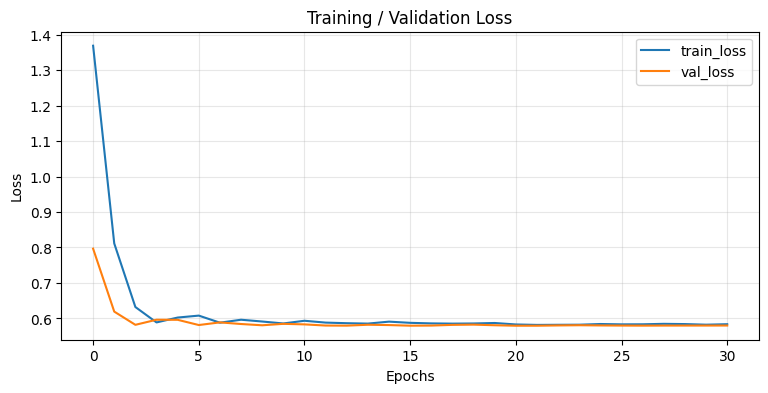

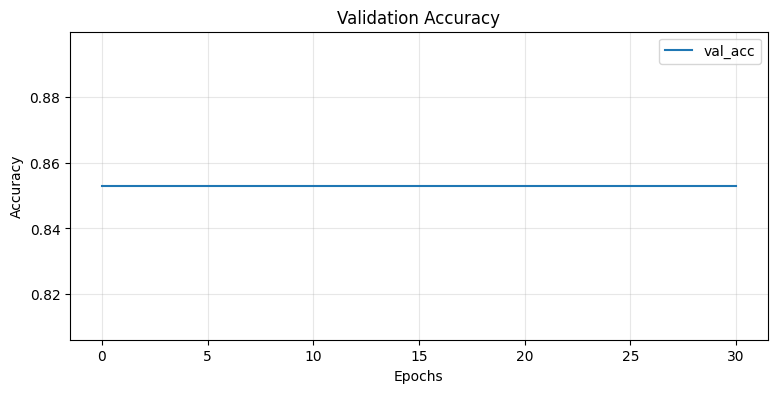

Baseline (always 'Normal') ~ overall accuracy: 85.31%


/tmp/ipython-input-4265807525.py:277: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  t_data = Data(edge_index=torch.tensor([t_src, t_dst], dtype=torch.long, device=DEVICE),


,src,dst,Packet_Size,Protocol,Encryption_Type,Packet_Delay(ms),Attack_label,Attack_label_pred
0,Node_7,Node_2,273,TCP,AES-192,8.83,?,Normal
1,Node_3,Node_4,845,UDP,AES-256,5.46,?,Normal
2,Node_1,Node_5,807,UDP,AES-128,7.28,?,Normal
3,Node_8,Node_7,1425,TCP,AES-128,7.51,?,Normal
4,Node_5,Node_2,883,TCP,AES-128,7.44,?,Normal
5,Node_7,Node_4,1333,TCP,AES-256,7.76,?,Normal
6,Node_9,Node_3,1392,TCP,AES-128,8.73,?,Normal
7,Node_3,Node_4,590,TCP,AES-192,10.17,?,Normal
8,Node_6,Node_3,1385,UDP,AES-128,13.07,?,Normal
9,Node_3,Node_9,1119,TCP,AES-128,11.88,?,Normal


In [2]:
import random, os
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.data import Data
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import TransformerConv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

########### 수정가능 부분 (하이퍼파라메타)
HID_DIM    = 128
HEADS      = 8
EDGE_DIM   = 32
EDGE_MLP_H = 128
DROPOUT    = 0.20
EPOCHS     = 200
LEARNING_RATE = 0.0015
WEIGHT_DECAY   = 3e-4
TEST_SIZE  = 0.20
VAL_SIZE   = 0.10
USE_CLASS_WEIGHTS = False   # <-- 정확도 최대화를 위해 금
LABEL_SMOOTHING   = 0.0
EARLY_STOP_PATIENCE = 30
MAKE_UNDIRECTED = True      # 양방향 엣지 추가
USE_SELF_LOOPS  = True
###########

def to_canonical_columns(df):
    d = {c:c.strip().lower() for c in df.columns}
    df = df.rename(columns=d)
    ren = {}
    if "src" in df.columns: ren["src"] = "src"
    if "dst" in df.columns: ren["dst"] = "dst"
    if "protocol" in df.columns: ren["protocol"] = "Protocol"
    if "encryption_type" in df.columns: ren["encryption_type"] = "Encryption_Type"
    if "packet_size" in df.columns: ren["packet_size"] = "Packet_Size"
    if "packet_delay(ms)" in df.columns: ren["packet_delay(ms)"] = "Packet_Delay(ms)"
    if "attack_label" in df.columns: ren["attack_label"] = "Attack_label"
    return df.rename(columns=ren)

# (1) Load local CSV
packets = pd.read_csv("packets.csv"); packets = to_canonical_columns(packets)
test2   = pd.read_csv("test2.csv");   test2   = to_canonical_columns(test2)

# Drop rows with missing Attack_label
packets.dropna(subset=['Attack_label'], inplace=True)

display(packets.head()); display(test2.head())

# (2) Graph build (edge classification)
all_nodes = sorted(set(packets['src']).union(set(packets['dst'])))
node2idx = {n:i for i,n in enumerate(all_nodes)}
num_nodes = len(all_nodes)

labels = sorted(packets['Attack_label'].dropna().unique())
label2idx = {l:i for i,l in enumerate(labels)}
idx2label = {i:l for l,i in label2idx.items()}

prot2idx = {p:i for i,p in enumerate(sorted(packets['Protocol'].dropna().unique()))}
enc2idx  = {e:i for i,e in enumerate(sorted(packets['Encryption_Type'].dropna().unique()))}

src_idx = packets['src'].map(node2idx).values
dst_idx = packets['dst'].map(node2idx).values
protocol_id   = packets['Protocol'].map(prot2idx).astype(int).values
encryption_id = packets['Encryption_Type'].map(enc2idx).astype(int).values

cont_cols = ['Packet_Size','Packet_Delay(ms)']
cont = packets[cont_cols].astype(float).values
scaler = StandardScaler(); cont_std = scaler.fit_transform(cont)
y = packets['Attack_label'].map(label2idx).astype(int).values

# Build edge_index with optional undirected edges
ei = np.vstack([src_idx, dst_idx])
if MAKE_UNDIRECTED:
    ei_rev = np.vstack([dst_idx, src_idx])
    ei = np.hstack([ei, ei_rev])

edge_index = torch.tensor(ei, dtype=torch.long)

# Duplicate edge features accordingly
if MAKE_UNDIRECTED:
    protocol_id = np.hstack([protocol_id, protocol_id])
    encryption_id = np.hstack([encryption_id, encryption_id])
    cont_std = np.vstack([cont_std, cont_std])
    y = np.hstack([y, y])  # duplicated labels for reverse edges

edge_proto = torch.tensor(protocol_id, dtype=torch.long)
edge_enc   = torch.tensor(encryption_id, dtype=torch.long)
edge_cont  = torch.tensor(cont_std, dtype=torch.float)
y_edge     = torch.tensor(y, dtype=torch.long)

# Optional self-loops (add placeholder features/labels for these)
if USE_SELF_LOOPS:
    num_orig_edges = edge_index.size(1)
    edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
    num_new_edges = edge_index.size(1)
    num_self_loops = num_new_edges - num_orig_edges

    # Add placeholder features for self-loops (e.g., 0 or average)
    # Using 0 for now, might need adjustment based on data
    placeholder_proto = torch.zeros(num_self_loops, dtype=torch.long)
    placeholder_enc = torch.zeros(num_self_loops, dtype=torch.long)
    placeholder_cont = torch.zeros(num_self_loops, edge_cont.size(1), dtype=torch.float)
    placeholder_y = torch.zeros(num_self_loops, dtype=torch.long) # Placeholder label

    edge_proto = torch.cat([edge_proto, placeholder_proto], dim=0)
    edge_enc = torch.cat([edge_enc, placeholder_enc], dim=0)
    edge_cont = torch.cat([edge_cont, placeholder_cont], dim=0)
    y_edge = torch.cat([y_edge, placeholder_y], dim=0)


data = Data(edge_index=edge_index, edge_proto=edge_proto, edge_enc=edge_enc, edge_cont=edge_cont, y=y_edge, num_nodes=num_nodes)

# Split over original (non-augmented) edges to avoid leakage between forward/reverse duplicates
orig_E = len(src_idx)
all_idx = np.arange(orig_E)
train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=SEED, stratify=y_edge[:orig_E].numpy())
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE/(1.0-TEST_SIZE), random_state=SEED, stratify=y_edge[train_idx].numpy())

# If we added undirected duplicates, map {i -> [i, i+orig_E]} as training set; else identity
if MAKE_UNDIRECTED:
    def expand(idx):
        idx = np.asarray(idx)
        return np.concatenate([idx, idx + orig_E])
    train_idx = torch.tensor(expand(train_idx), dtype=torch.long)
    val_idx   = torch.tensor(expand(val_idx),   dtype=torch.long)
    test_idx  = torch.tensor(expand(test_idx),  dtype=torch.long)
else:
    train_idx = torch.tensor(train_idx, dtype=torch.long)
    val_idx   = torch.tensor(val_idx, dtype=torch.long)
    test_idx  = torch.tensor(test_idx, dtype=torch.long)

from torch.nn import LayerNorm

class EdgeFeatureEncoder(nn.Module):
    def __init__(self, num_protocols, num_encryptions, cont_dim=2, emb_dim_each=12, proj_dim=EDGE_DIM):
        super().__init__()
        self.prot_emb = nn.Embedding(num_protocols, emb_dim_each)
        self.enc_emb  = nn.Embedding(num_encryptions, emb_dim_each)
        self.cont_proj = nn.Sequential(nn.Linear(cont_dim, emb_dim_each), nn.GELU(), nn.Linear(emb_dim_each, emb_dim_each))
        self.proj = nn.Linear(emb_dim_each*3, proj_dim)
        self.act = nn.GELU()
    def forward(self, edge_proto, edge_enc, edge_cont):
        e = torch.cat([self.prot_emb(edge_proto), self.enc_emb(edge_enc), self.cont_proj(edge_cont)], dim=-1)
        return self.proj(self.act(e)), e

class MyEdgeGAT(nn.Module):
    def __init__(self, num_nodes, num_classes, heads=HEADS, hid=HID_DIM, edge_dim=EDGE_DIM, dropout=DROPOUT,
                 num_protocols=2, num_encryptions=3, cont_dim=2, edge_mlp_h=EDGE_MLP_H):
        super().__init__()
        self.dropout = dropout
        self.node_emb = nn.Embedding(num_nodes, hid)
        self.efe = EdgeFeatureEncoder(num_protocols, num_encryptions, cont_dim=cont_dim, emb_dim_each=12, proj_dim=edge_dim)
        self.conv1 = TransformerConv(hid, hid, heads=heads, concat=True, dropout=dropout, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hid*heads, hid, heads=heads, concat=True, dropout=dropout, edge_dim=edge_dim)
        self.conv3 = TransformerConv(hid*heads, hid, heads=1, concat=False, dropout=dropout, edge_dim=edge_dim)
        self.norm1 = LayerNorm(hid*heads); self.norm2 = LayerNorm(hid*heads); self.norm3 = LayerNorm(hid)
        in_edge = hid + hid + (12*3)
        self.edge_mlp = nn.Sequential(nn.Linear(in_edge, edge_mlp_h), nn.GELU(), nn.Dropout(dropout), nn.Linear(edge_mlp_h, num_classes))
    def forward(self, data):
        conv_edge, mlp_edge = self.efe(data.edge_proto, data.edge_enc, data.edge_cont)
        x = self.node_emb.weight
        x1 = self.conv1(x, data.edge_index, edge_attr=conv_edge); x1 = self.norm1(x1); x1 = F.gelu(x1); x1 = F.dropout(x1, p=self.dropout, training=self.training)
        x2 = self.conv2(x1, data.edge_index, edge_attr=conv_edge); x2 = self.norm2(x2); x2 = F.gelu(x2); x2 = F.dropout(x2, p=self.dropout, training=self.training)
        x3 = self.conv3(x2, data.edge_index, edge_attr=conv_edge); x3 = self.norm3(x3); x3 = F.gelu(x3); x3 = F.dropout(x3, p=self.dropout, training=self.training)
        src, dst = data.edge_index[0], data.edge_index[1]
        edge_repr = torch.cat([x3[src], x3[dst], mlp_edge], dim=-1)
        return self.edge_mlp(edge_repr)

############# 수정가능 부분 (최적화부분)
model = MyEdgeGAT(num_nodes=data.num_nodes, num_classes=len(labels), heads=HEADS, hid=HID_DIM, edge_dim=EDGE_DIM, dropout=DROPOUT,
                  num_protocols=len(prot2idx), num_encryptions=len(enc2idx), cont_dim=2, edge_mlp_h=EDGE_MLP_H).to(DEVICE)

loss_function = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING).to(DEVICE)  # no class weights
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=max(LEARNING_RATE*0.1, 1e-5))

def accuracy_from_logits(logits, y_true):
    preds = logits.argmax(dim=-1)
    return (preds == y_true).float().mean().item()

best_val_acc = -1.0
best_state = None
loss_history = []
val_acc_hist = []
patience_left = EARLY_STOP_PATIENCE

data = data.to(DEVICE)
train_idx_ = train_idx.to(DEVICE)
val_idx_   = val_idx.to(DEVICE)
test_idx_  = test_idx.to(DEVICE)

for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()
    logits = model(data)
    loss = loss_function(logits[train_idx_], data.y[train_idx_])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        logits_eval = model(data)
        val_loss = loss_function(logits_eval[val_idx_], data.y[val_idx_]).item()
        train_acc = accuracy_from_logits(logits_eval[train_idx_], data.y[train_idx_])
        val_acc   = accuracy_from_logits(logits_eval[val_idx_], data.y[val_idx_])
    loss_history.append((loss.item(), val_loss))
    val_acc_hist.append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        patience_left = EARLY_STOP_PATIENCE
    else:
        patience_left -= 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"[{epoch:4d}] train_loss={loss.item():.4f} val_loss={val_loss:.4f} | train_acc={train_acc:.3f} val_acc={val_acc:.3f} (best={best_val_acc:.3f})")

    if patience_left <= 0:
        print("Early stopping (val_acc).")
        break

if best_state is not None:
    model.load_state_dict(best_state)

# (5) Evaluate on test set
model.eval()
with torch.no_grad():
    logits_all = model(data)
    test_acc = accuracy_from_logits(logits_all[test_idx_], data.y[test_idx_])
print(f"\n✅ Test Accuracy (no class weights): {test_acc*100:.2f}%")

# (6) Loss + Val-Acc curves
train_losses = [t for t,v in loss_history]; val_losses = [v for t,v in loss_history]
plt.figure(figsize=(9,4)); plt.plot(train_losses, label="train_loss"); plt.plot(val_losses, label="val_loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.title("Training / Validation Loss"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(9,4)); plt.plot(val_acc_hist, label="val_acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.title("Validation Accuracy"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Baseline (Always Normal) accuracy on test split for reference
# map test_idx back to original indices range [0, orig_E)
orig_E = len(packets)
# For clarity, recompute majority class acc on non-augmented split size
maj = packets['Attack_label'].mode()[0]
maj_acc = (packets['Attack_label'].iloc[:orig_E].isin([maj]).mean())*100.0
print(f"Baseline (always '{maj}') ~ overall accuracy: {maj_acc:.2f}%")

# (7) Predict test2 (display only)
t_src = test2['src'].map(node2idx); t_dst = test2['dst'].map(node2idx)
if t_src.isna().any() or t_dst.isna().any():
    missing = set(test2['src'][t_src.isna()]).union(set(test2['dst'][t_dst.isna()]))
    for n in missing: node2idx[n] = len(node2idx)
    old = model.node_emb.weight.data; new = nn.Embedding(len(node2idx), old.size(1)).to(DEVICE); nn.init.normal_(new.weight, 0.0, 0.02)
    with torch.no_grad(): new.weight[:old.size(0)] = old
    model.node_emb = new

t_src = test2['src'].map(node2idx).astype(int).values; t_dst = test2['dst'].map(node2idx).astype(int).values
t_protocol_id   = test2['Protocol'].map(prot2idx).astype(int).values
t_encryption_id = test2['Encryption_Type'].map(enc2idx).astype(int).values
t_cont_std = scaler.transform(test2[cont_cols].astype(float).values)

# If undirected during training, also use undirected for inference (but we only need forward direction edges for display)
from torch_geometric.data import Data
t_data = Data(edge_index=torch.tensor([t_src, t_dst], dtype=torch.long, device=DEVICE),
              edge_proto=torch.tensor(t_protocol_id, dtype=torch.long, device=DEVICE),
              edge_enc=torch.tensor(t_encryption_id, dtype=torch.long, device=DEVICE),
              edge_cont=torch.tensor(t_cont_std, dtype=torch.float, device=DEVICE),
              num_nodes=len(node2idx))
with torch.no_grad(): t_pred = model(t_data).argmax(dim=-1).cpu().numpy()
idx2label = {v:k for k,v in label2idx.items()}
out = test2.copy(); out['Attack_label_pred'] = [idx2label[i] for i in t_pred]
display(out)

In [3]:
# (8) Save predictions to CSV
out.to_csv("test2_pred.csv", index=False)

print("✅ Predictions saved to test2_pred.csv")

✅ Predictions saved to test2_pred.csv
